# MSE Loss Training

Trains AdEx parameters on a single experimental trace using direct voltage MSE loss.
Demonstrates the baseline approach and its known failure mode (converging to non-spiking solutions).

In [15]:
import logging

import jax
import jax.numpy as jnp
import numpy as np
from jax import config

from ADoptEX.core.data import crop_to_stim_window, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, PARAM_BOUNDS, NAUD_PARAMETERS
from ADoptEX.core.simulation import simulate_jaxley
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    make_guarino_loss_fn,
    GuarinoFeatures,
    extract_experimental_features,
    guarino_loss,
    GuarinoLossConfig,
)
from ADoptEX.loss.mse import MSELossConfig, make_mse_loss_fn
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_history_plot,
)
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

## 1. Load Data

In [16]:
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

#trace = load_trace(
#    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_553.dat",
#    current_path=DATA_DIR + "ECBL_IDthresh_ch4_553.dat",
#)

trace = load_trace(
    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_541.dat",
    current_path=DATA_DIR + "ECBL_IDthresh_ch4_541.dat",
)

print(
    f"Loaded trace: {trace.n_samples} samples, dt={trace.dt_ms:.3f} ms, duration={trace.duration_ms:.1f} ms"
)
print(
    f"Stim window: {trace.stim_start_idx} - {trace.stim_end_idx} ({trace.stim_duration_ms:.1f} ms)"
)
print(f"Stim current: {trace.stim_current_pA:.1f} pA")
print(f"Detected spikes: {trace.n_spikes}")

Loaded trace: 30000 samples, dt=0.100 ms, duration=2999.9 ms
Stim window: 7001 - 27001 (2000.0 ms)
Stim current: 327.3 pA
Detected spikes: 0


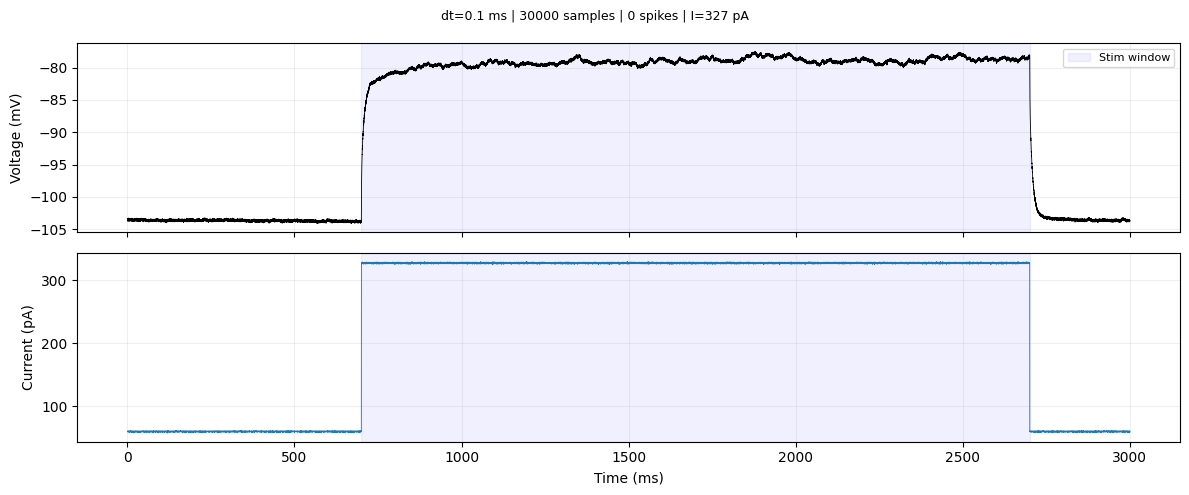

In [17]:
trace_plot(trace);

Cropped trace: 5150 samples, 510.0 ms
Spikes in window: 0 at [] ms


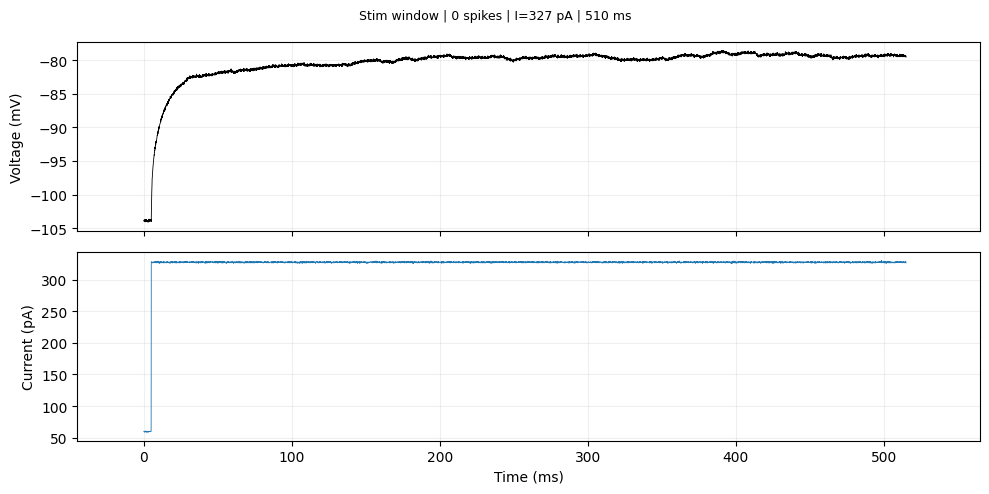

In [18]:
# Crop to stimulation window (500 ms max)
data = crop_to_stim_window(trace, max_duration_ms=510.0, padding_ms_before=5.0)

print(f"Cropped trace: {data.n_samples} samples, {data.stim_duration_ms:.1f} ms")
print(f"Spikes in window: {data.n_spikes} at {data.spike_times.round(1)} ms")

trace_stim_window_plot(data);

## 2. Initial Simulation

Run a forward simulation with default parameters to check that the setup works before training.

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Initial simulation: 0 spikes, firing rate 0.0 Hz
Experimental:       0 spikes


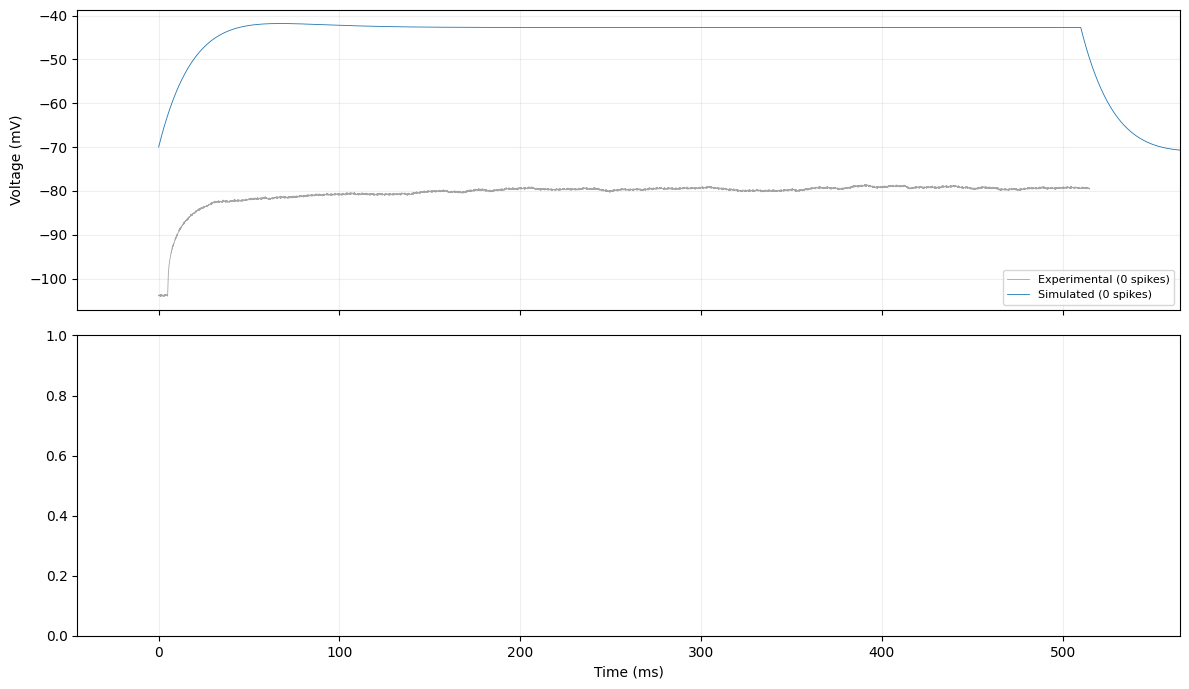

In [19]:
# initial_params = dict(DEFAULT_PARAMS)
initial_params = dict(NAUD_PARAMETERS["tonic"])
initial_params["v_threshold"] = 0.0  # required by create_adex_cell
# initial_params["a"] = -0.0
# initial_params["b"] = 10.0

# initial_params["g_L"] =
# initial_params["C_m"] =
# initial_params["E_L"] =
initial_params["v_reset"] = -80
initial_params["v_T"] = -20

# Run forward simulation with step current matching experimental stim
sim_init = simulate_jaxley(
    params=initial_params,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(
    f"Initial simulation: {sim_init.n_spikes} spikes, firing rate {sim_init.firing_rate_hz:.1f} Hz"
)
print(f"Experimental:       {data.n_spikes} spikes")

fit_comparison_plot(data, sim_init);

## 3. Training Setup

In [20]:
# data.current is already in pA; setup_trainable_cell() converts to nA internally
current_trace_pA = jnp.array(data.current)

"""
training_config = TrainingConfig(
    optimizer="adam",
    learning_rate=0.005,
    n_epochs=1000,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    clip_to_bounds=True,
    print_every=100,
    verbose=True,
    return_best=True,
    grad_clip_norm=10,
    lr_schedule="constant",
    # lr_decay_rate=0.01 # interesting for exponential decay
)
"""

# --- Polyak gradient normalization (Deistler et al. 2025) ---
# To use Polyak instead of Adam, replace the config above with:

training_config = TrainingConfig(
    optimizer="adam",
    learning_rate=0.1,  # base LR (scaled by loss each step)
    n_epochs=100,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=50,
    #polyak_alpha=1.0,  # loss exponent: effective_lr = lr * loss^alpha
    #polyak_beta=0.85,  # grad norm exponent: grad / ||grad||^beta
    clip_to_bounds=False,
    use_param_transform=True,  # sigmoid reparameterization (roadmap item 4)
    verbose=True,
    return_best=True,
    # trainable_params=['C_m', 'g_L', 'E_L'],
    trainable_params=["g_L", "E_L", "v_reset", "C_m"],
    # NOTE: grad_clip_norm and lr_schedule are incompatible with polyak
    #       (normalization replaces clipping; loss scaling replaces scheduling)
)

# The update rule is: params -= lr * loss^alpha * grad / ||grad||^beta
# With defaults (alpha=1, beta=1): step size automatically shrinks as loss decreases.
# lr_history in TrainingResult tracks the effective LR each epoch.

# Create trainable cell with data stimulation
cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=current_trace_pA, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    config=training_config,
)

print("Trainable parameters:")
for p in trainable_params:
    for k, v in p.items():
        print(f"  {k}: {float(v.flatten()[0]):.4f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Trainable parameters:
  AdEx_g_L: 10.0000
  AdEx_E_L: -70.0000
  AdEx_v_reset: -80.0000
  capacitance: 200.0000


In [21]:
# Create loss function
exp_voltage = jnp.array(data.voltage)

loss_fn = make_mse_loss_fn(cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=data.dt_ms, exp_voltage=exp_voltage, stim_end_index=data.stim_end_idx, loss_config=MSELossConfig(normalize=False, clamp_threshold=None))


"""
# Extract target features from experimental trace (hard spike detection)
exp_features = extract_experimental_features(
    voltage_trace=exp_voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
)

loss_fn = make_guarino_loss_fn(cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=data.dt_ms, exp_features=exp_features, stim_duration_ms=data.stim_duration_ms, stim_end_index=data.stim_end_idx, loss_config=GuarinoLossConfig(weight_t_first=25.0, weight_t_last=5.0, weight_firing_freq=10.0, weight_spike_count=0.1))
"""

# Verify loss computes
loss_initial = loss_fn(trainable_params)
print(f"Initial loss: {float(loss_initial):.4f}")

Initial loss: 1369.6052


## 4. Train

In [22]:
result = train(
    loss_fn=loss_fn,
    trainable_params=trainable_params,
    config=training_config,
    initial_params=initial_params,
)

print(f"\nTraining complete.")
print(f"  Final loss:  {result.final_loss:.4f} mV²")
print(
    f"  Total time:  {result.total_time:.1f} s ({result.mean_time_per_epoch*1000:.0f} ms/epoch)"
)

Training: optimizer=adam lr=0.1 epochs=100 surrogate=sigmoid slope=5.0 sigmoid_transform
Epoch    0 | loss=1369.605347 | grad_norm=6.69e+02 | g_L=10.3788, E_L=-70.4735, v_reset=-80.0000, C_m=211.7547
Epoch   50 | loss=15.640206 | grad_norm=9.41e+00 | g_L=27.6254, E_L=-91.3536, v_reset=-80.0000, C_m=384.6511
Training complete: final_loss=14.284700 best_loss=14.284700 (epoch 99) total_time=0.5s mean_epoch=5.5ms [returning best]



Training complete.
  Final loss:  14.2847 mV²
  Total time:  0.5 s (5 ms/epoch)


## 5. Results

In [23]:
# Show trained parameter values (text summary)
trained = result.get_params_dict()
print("Trained parameters (vs initial):")
print(f"{'Parameter':<12} {'Initial':>10} {'Trained':>10} {'Bounds':>20}")
print("-" * 55)
for k, v in trained.items():
    init_v = initial_params.get(k, float("nan"))
    bounds = PARAM_BOUNDS.get(k)
    bounds_str = f"[{bounds.min}, {bounds.max}]" if bounds else ""
    print(f"{k:<12} {init_v:>10.3f} {v:>10.3f} {bounds_str:>20}")

Trained parameters (vs initial):
Parameter       Initial    Trained               Bounds
-------------------------------------------------------
g_L              10.000     28.200          [6.0, 50.0]
E_L             -70.000    -91.048      [-120.0, -65.0]
v_reset         -80.000    -80.000       [-90.0, -45.0]
C_m             200.000    303.674        [10.0, 500.0]


In [24]:
# Final simulation with trained parameters
trained = result.get_params_dict()
trained_full = dict(initial_params)
trained_full.update(trained)

sim_trained = simulate_jaxley(
    params=trained_full,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=False,  # exact simulation for evaluation
)

print(f"Trained simulation: {sim_trained.n_spikes} spikes")
print(f"Experimental:       {data.n_spikes} spikes")

if sim_trained.n_spikes > 0 and data.n_spikes > 0:
    cf = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_trained.spike_times,
        duration_ms=data.stim_duration_ms,
    )
    print(f"Coincidence factor Gamma = {cf.gamma:.3f} (target > 0.5)")
else:
    cf = None
    print("Coincidence factor: N/A (one trace has no spikes)")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Trained simulation: 0 spikes
Experimental:       0 spikes
Coincidence factor: N/A (one trace has no spikes)


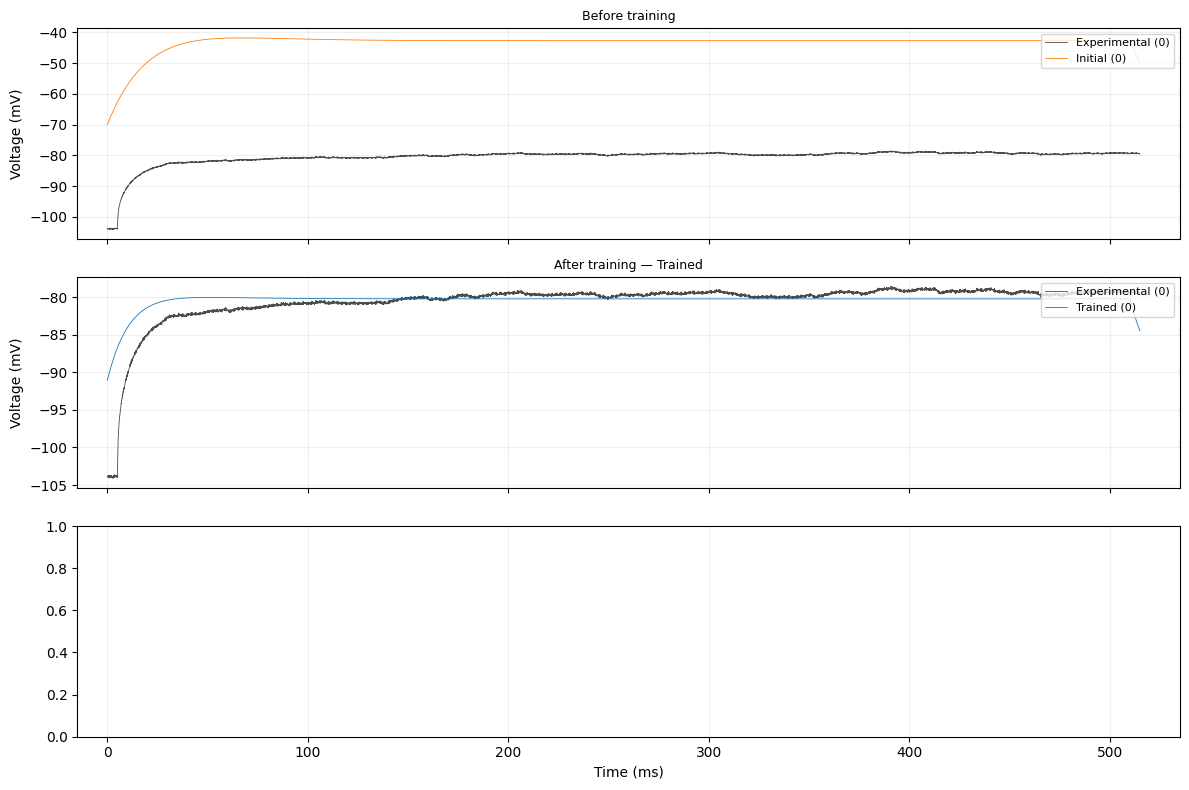

In [25]:
fit_before_after_plot(data, sim_init, sim_trained, coincidence=cf);

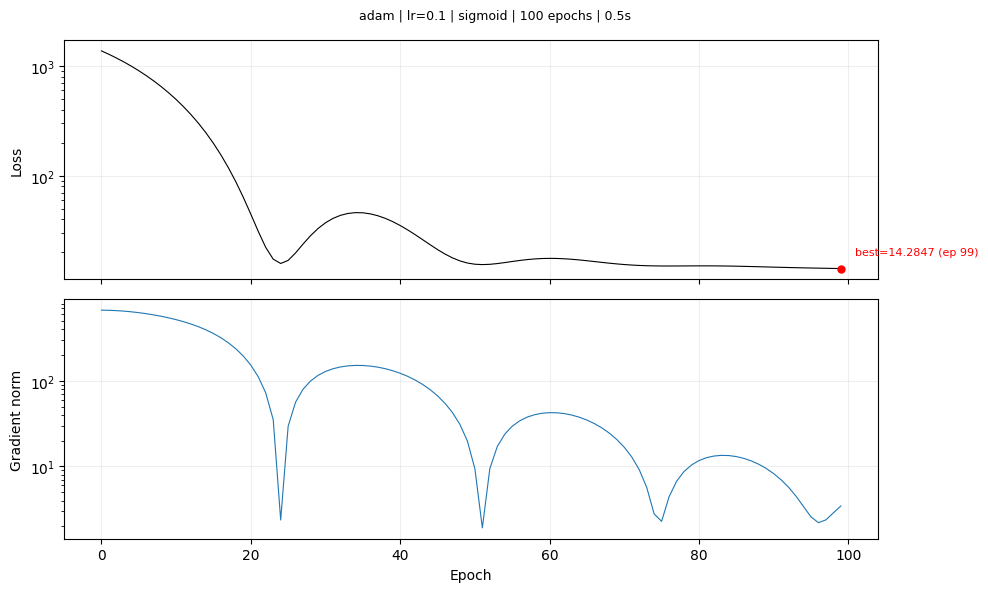

In [26]:
training_history_plot(result);

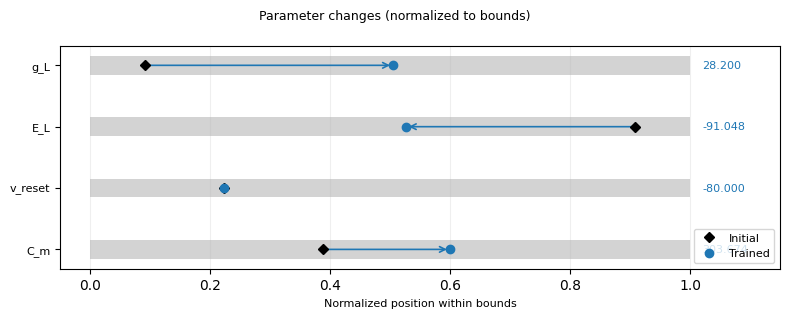

In [27]:
parameter_comparison_plot(result);

In [28]:
if cf is not None:
    spike_timing_plot(data, sim_trained, cf)
else:
    print("Spike timing plot skipped (no coincidence result)")

Spike timing plot skipped (no coincidence result)
